todo
- пересобрать все в функции
- добавить возможность сохранения распределения вероятностей
- впендюрить в основной код

In [1]:

from pathlib import Path
import matplotlib.pyplot as plt
import sys

PROJECT_ROOT = Path.cwd()

while PROJECT_ROOT.name != "through_vlm_guidance_research_dev":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import torch
from transformers import AutoProcessor, Qwen3VLForConditionalGeneration
from PIL import Image
from pathlib import Path
from modules.utils import choose_device


MODEL_ID = 'Qwen/Qwen3-VL-2B-Instruct'
SOURCE_DIR = Path('../../sources')
device = choose_device()
image = Image.open('../../datasets/image.png').convert('RGB')


/opt/miniconda3/envs/through_guidance/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device = 'mps'


In [8]:
image.getdata

<bound method Image.getdata of <PIL.Image.Image image mode=RGB size=500x333 at 0x12DDB8E90>>

In [3]:
processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    cache_dir=SOURCE_DIR,
)

model = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    cache_dir=SOURCE_DIR,
    dtype='auto',
).to(device)

model.eval()

messages = [
    {
        'role': 'system',
        'content': [
            {
                'type': 'text',
                'text': 'You are a visual binary classifier. Answer with exactly one word: Yes or No.',
            }
        ],
    },
    {
        'role': 'user',
        'content': [
            {'type': 'image', 'image': image},
            {
                'type': 'text',
                'text': (
                    'Question: Does this image show a forest?\n'
                    'Valid answers: Yes, No.\n'
                    'Answer:'
                ),
            },
        ],
    },
]

inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors='pt',
)

inputs = inputs.to(device)


Loading weights: 100%|██████████| 625/625 [00:00<00:00, 3322.12it/s]


In [4]:
for param in model.parameters():
    param.requires_grad_(False)

pixel_key = 'pixel_values'

inputs[pixel_key] = inputs[pixel_key].detach().clone()
inputs[pixel_key].requires_grad_(True)

tensor([[ 0.0588, -0.7412, -0.8745,  ..., -0.8431, -0.8667, -0.9059],
        [-0.8431, -0.8745, -0.8510,  ..., -0.9137, -0.9294, -0.8980],
        [-0.9059, -0.9137, -0.9059,  ..., -0.7490, -0.8118, -0.8745],
        ...,
        [-0.2549, -0.3176, -0.3176,  ..., -0.6784, -0.7176, -0.7725],
        [-0.3020, -0.2157, -0.2549,  ..., -0.8275, -0.8275, -0.7961],
        [-0.4745, -0.4118, -0.3647,  ..., -0.7020, -0.7333, -0.7804]],
       device='mps:0', requires_grad=True)

In [5]:
yes_variants = ['Yes', 'yes', 'YES', ' Yes', ' yes']
no_variants = ['No', 'no', 'NO', ' No', ' no']


def signle_token_ids(tokens):
    token_ids = []
    
    for token in tokens:
        ids = processor.tokenizer.encode(token, add_special_tokens=False)
        pieces = [processor.decode([token_id], skip_special_tokens=False) for token_id in ids]
        print(token, repr(token), ids, pieces)
        
        if len(ids) == 1:
            token_ids.append(ids[0])

    return token_ids


yes_ids = signle_token_ids(yes_variants)
no_ids = signle_token_ids(no_variants)

yes_ids = torch.tensor(yes_ids)
no_ids = torch.tensor(no_ids)


Yes 'Yes' [9454] ['Yes']
yes 'yes' [9693] ['yes']
YES 'YES' [14004] ['YES']
 Yes ' Yes' [7414] [' Yes']
 yes ' yes' [9834] [' yes']
No 'No' [2753] ['No']
no 'no' [2152] ['no']
NO 'NO' [8996] ['NO']
 No ' No' [2308] [' No']
 no ' no' [902] [' no']


In [6]:
outputs = model(**inputs)

logits = outputs.logits
last_logit = logits[0, -1, :].to(dtype=torch.float32)


In [7]:

def yes_no_loss(last_logit, yes_variants=yes_ids, no_variants=no_ids):
    # -log(sigma(p_yes - p_no))

    
    yes_score = torch.logsumexp(last_logit[yes_variants], dim=0)
    no_score = torch.logsumexp(last_logit[no_variants], dim=0)
    margin = yes_score - no_score
    
    return torch.nn.functional.softplus(-margin)
    
    
    
model.zero_grad(set_to_none=True)
if inputs[pixel_key].grad is not None:
    inputs[pixel_key].grad.zero_()
    

In [8]:
loss = yes_no_loss(last_logit)

loss.backward()

In [9]:
probs = torch.softmax(last_logit.detach().cpu().float(), dim=-1)

top_k = 50
top_probs, top_token_ids = torch.topk(probs, k=top_k)
top_token_texts = []

for prob, token_id in zip(top_probs, top_token_ids):
    token_id = token_id.item()
    token_text = processor.decode([token_id], skip_special_tokens=False)
    top_token_texts.append(token_text)
    print(f'{token_id:>8}  {prob.item():.3e}  {repr(token_text)}')


top_probs = top_probs.to(dtype=torch.float32, device='cpu').numpy()


    9454  1.000e+00  'Yes'
    2753  1.125e-07  'No'
    9693  1.692e-10  'yes'
   14004  6.224e-11  'YES'
    7414  6.224e-11  ' Yes'
      56  8.423e-12  'Y'
    2514  2.735e-12  'True'
   57741  2.413e-12  '"Yes'
   86475  1.659e-12  'Ye'
   23336  5.385e-13  'Yeah'
    2623  1.748e-13  'Not'
    2610  1.543e-13  'You'
   16141  1.543e-13  'Answer'
      32  1.060e-13  'A'
   85408  8.258e-14  '“Yes'
   39814  8.258e-14  'Sure'
    9834  6.431e-14  ' yes'
   28715  6.431e-14  'Based'
     785  3.901e-14  'The'
    3872  3.038e-14  'Is'
    3838  2.366e-14  'What'
    1249  2.088e-14  'To'
   87543  1.626e-14  'Yep'
    3966  1.626e-14  'One'
   64725  1.435e-14  'Yo'
   10234  1.266e-14  'Why'
    1654  1.266e-14  'We'
   62893  1.266e-14  'Ya'
    1986  1.266e-14  'This'
   14190  1.118e-14  'Wait'
   10061  1.118e-14  'Let'
    9707  9.863e-15  'Hello'
   43523  8.704e-15  'Indeed'
   32313  5.279e-15  'Okay'
    7661  5.279e-15  'More'
    7771  5.279e-15  'Your'
   11908  4.111e

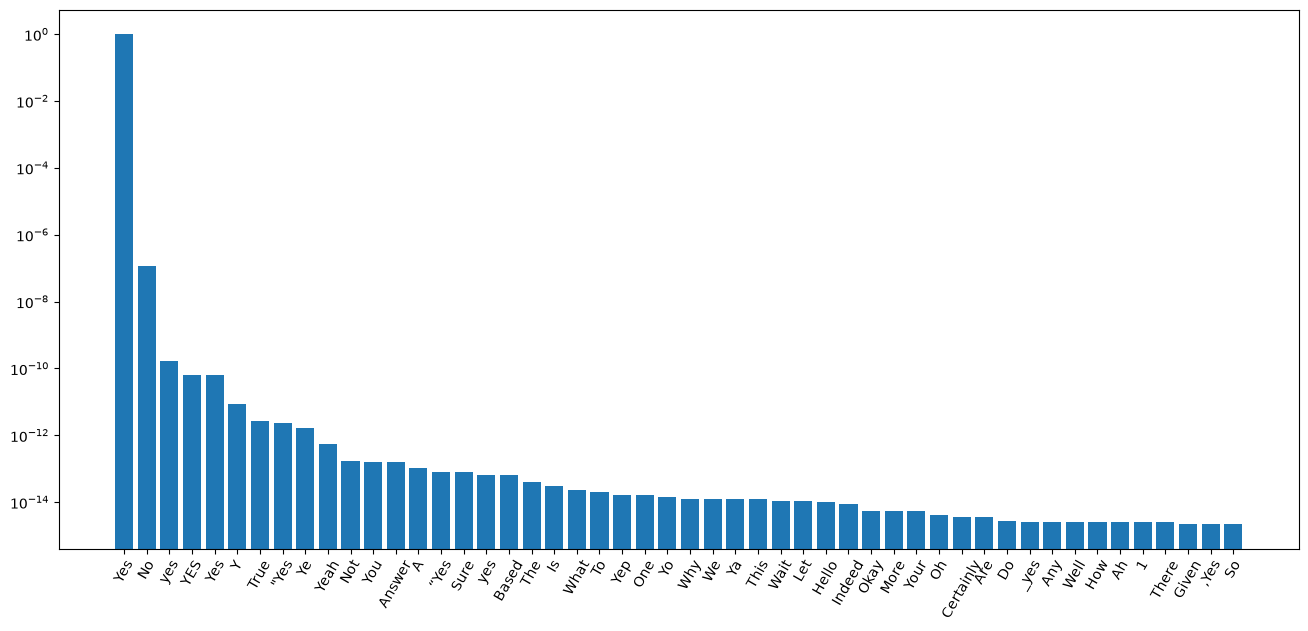

In [10]:
plt.figure(figsize=(16, 7))
plt.bar(top_token_texts, top_probs)
plt.yscale('log')
plt.xticks(rotation=60,)
plt.show()


In [11]:
yes_variants = ['Yes', ' yes', ' Yes', '\nYes']
no_variants = ['No', ' no', ' No', '\nNo']


def single_token_ids(variants):
    token_ids = []

    for text in variants:
        ids = processor.tokenizer.encode(text, add_special_tokens=False)
        pieces = [processor.decode([token_id], skip_special_tokens=False) for token_id in ids]
        print(repr(text), ids, pieces)

        if len(ids) == 1:
            token_ids.append(ids[0])

    return token_ids


yes_ids = single_token_ids(yes_variants)
no_ids = single_token_ids(no_variants)

last_logit = logits[0, -1, :]
probs = torch.softmax(last_logit.float(), dim=-1)

p_yes = probs[yes_ids].sum()
p_no = probs[no_ids].sum()

p_binary_yes = p_yes / (p_yes + p_no)
p_binary_no = p_no / (p_yes + p_no)

print('yes ids:', yes_ids)
print('no ids:', no_ids)
print('raw p_yes:', p_yes.item())
print('raw p_no:', p_no.item())
print('binary p_yes:', p_binary_yes.item())
print('binary p_no:', p_binary_no.item())


'Yes' [9454] ['Yes']
' yes' [9834] [' yes']
' Yes' [7414] [' Yes']
'\nYes' [198, 9454] ['\n', 'Yes']
'No' [2753] ['No']
' no' [902] [' no']
' No' [2308] [' No']
'\nNo' [198, 2753] ['\n', 'No']
yes ids: [9454, 9834, 7414]
no ids: [2753, 902, 2308]
raw p_yes: 0.9999998807907104
raw p_no: 1.1253516873921399e-07
binary p_yes: 0.9999998807907104
binary p_no: 1.1253516873921399e-07
